Question 1:<br>
Variables:<br>
V(D, P, H) where: <br>
H ∈ {H1, ..., H14}<br>
P ∈ {P1, P2, P3, P4}<br>
D ∈ {Sunday, Monday, Tuesday, Wednesday, Thursday}<br>
Each variable represents the assignment of a proctor R to a specific hall H in period P of day D<br>
Total number of variables: 14 halls * 4 periods * 5 days = 280 variables<br>
Domains:<br>
D(V) = {R1, R2, ..., R30}<br>
Constraints:<br>
1. V(D, P, H) ∈ AvailableProctors(D)
2. Count (V(D, P, H) = Ri) ≤ 3  for all P and H on day D
3. V(D1, P1, H1) ≠ V(D2, P2, H2)  for all H1 ≠ H2, D1 = D2, P1 = P2
4. H1 ≠ H2  for all V(D1, P1, H1) = V(D2, P2, H2), P1 ≠ P2, D1 = D2
5. ∀ H, D, P,  Ǝ V(D, P, H)

Question 2: <br>
The problem is infeasible because the total number of required assignments is 280, and the possible assignments under the given constraints is 30 procators * 3 days * 3 periods = 270. There is a gap of 10 slots. <br>
We have 3 options to solve this: 
1. Increase number of procators to 32.
2. Increase working days to 4 for each procator.
3. Increase daily limit to 4 periods for each procator. <br>
4. Decrease the number of halls and proctors.<br>
Options 1,2 and 3 will increase the problem size with tighter constraints. We will go with option 4 as to make the problem size smaller and feasible

C:\Users\user\AppData\Local\Temp\ipykernel_20724\3066249237.py:58: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, edgelist=c3_edges, edge_color='tomato',
C:\Users\user\AppData\Local\Temp\ipykernel_20724\3066249237.py:62: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, edgelist=c4_edges, edge_color='royalblue',


Graph initialized with 16 variables and 48 constraints.


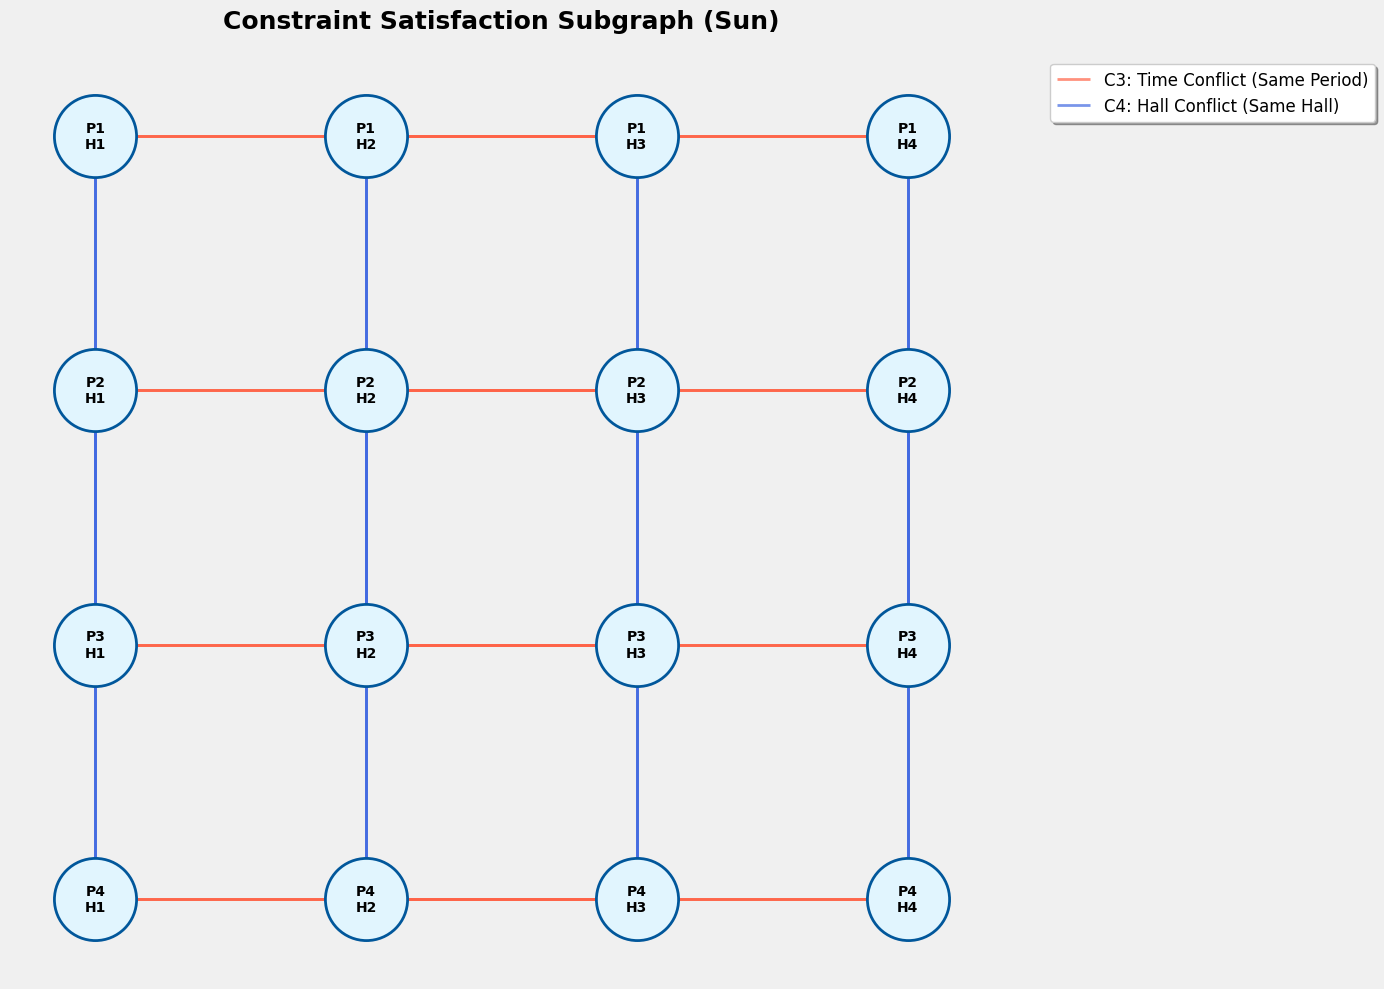

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Problem Configuration ---
G = nx.Graph()
DAY = "Sun"
PERIODS = ["P1", "P2", "P3", "P4"]
HALLS = ["H1", "H2", "H3", "H4"]

# Define Nodes using the order (Day, Period, Hall)
# We store them in a list to maintain order and a dict for positioning
variables = [(DAY, p, h) for p in PERIODS for h in HALLS]
G.add_nodes_from(variables)

# --- 2. Professional Constraint Mapping ---
for i, var1 in enumerate(variables):
    d1, p1, h1 = var1
    for j, var2 in enumerate(variables):
        if i >= j: continue  # Avoid self-loops and duplicate edges
        d2, p2, h2 = var2

        # C3: Time Overlap Conflict
        # "A proctor cannot be in two different halls during the same period"
        if p1 == p2 and h1 != h2:
            G.add_edge(var1, var2, label='C3', color='tomato')

        # C4: Hall History Conflict
        # "A proctor cannot monitor the same hall twice in one day"
        if h1 == h2 and p1 != p2:
            G.add_edge(var1, var2, label='C4', color='royalblue')

# --- 3. Visualization Setup ---
plt.figure(figsize=(14, 10), facecolor='#f0f0f0')

# Professional Grid Positioning: 
# X-axis = Halls, Y-axis = Periods (inverted so P1 is at the top)
pos = {}
for i, p in enumerate(PERIODS):
    for j, h in enumerate(HALLS):
        pos[(DAY, p, h)] = (j, len(PERIODS) - i)

# Draw Nodes with a professional aesthetic
nx.draw_networkx_nodes(G, pos, 
                       node_size=3500, 
                       node_color='#e1f5fe', 
                       edgecolors='#01579b', 
                       linewidths=2)

# Professional Labels
node_labels = {node: f"{node[1]}\n{node[2]}" for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight='bold', font_family='sans-serif')

# Separate edges for legend and styling
# Use (u, v, d) to unpack the source, target, and data dictionary
c3_edges = [(u, v) for u, v, d in G.edges(data=True) if d['label'] == 'C3']
c4_edges = [(u, v) for u, v, d in G.edges(data=True) if d['label'] == 'C4']
# Draw Edges with curved lines (connectionstyle) for better clarity
nx.draw_networkx_edges(G, pos, edgelist=c3_edges, edge_color='tomato', 
                       width=2, alpha=0.7, label='C3: Time Conflict (Same Period)',
                       connectionstyle="arc3,rad=0.1")

nx.draw_networkx_edges(G, pos, edgelist=c4_edges, edge_color='royalblue', 
                       width=2, alpha=0.7, label='C4: Hall Conflict (Same Hall)',
                       connectionstyle="arc3,rad=0.1")

# --- 4. Polish & Export ---
plt.title(f"Constraint Satisfaction Subgraph ({DAY})", fontsize=18, fontweight='bold', pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, frameon=True, shadow=True)

# Remove axes and add margin
plt.tight_layout()
plt.axis('off')

print(f"Graph initialized with {G.number_of_nodes()} variables and {G.number_of_edges()} constraints.")
plt.show()

Question 3:Standard backtracking algorithm 

In [135]:
import time

# --- 1. Problem Configuration ---
DAYS = ['Sun', 'Mon', 'Tue','Wed', 'Thu']
PERIODS = ['P1', 'P2', 'P3', 'P4']
HALLS = [f'H{i}' for i in range(1, 8)] 
PROCTORS = [f'R{i}' for i in range(1, 24)] 

# All variables to be assigned
VARIABLES = [(d, p, h) for d in DAYS for p in PERIODS for h in HALLS ]

# Constraints Data
# proctor_schedules = {f'R{i}': [DAYS[i%5], DAYS[(i+1)%5], DAYS[(i+2)%5]] for i in range(1, 17)}
# State Tracking
proctor_daily_load = {(d, r): 0 for d in DAYS for r in PROCTORS}
proctor_busy_period = {(d, p, r): False for d in DAYS for p in PERIODS for r in PROCTORS}
proctor_hall_history = {(d, h, r): False for d in DAYS for h in HALLS for r in PROCTORS}

stats = {
    "nodes_explored": 0,
    "bt_count": 0
}

def find_unassigned(assignment):
    """Equivalent to find_empty in Sudoku code."""
    for var in VARIABLES:
        if var not in assignment:
            return var
    return None

def is_valid(var, proctor, assignment):
    """Equivalent to is_valid in Sudoku code."""
    day, period, hall = var
    
    # Replace your C1 check in Code 1 with this logic:
    # Check if proctor already works this day OR has worked fewer than 3 days total
    days_worked = [d for d in DAYS if proctor_daily_load[(d, proctor)] > 0]
    if day not in days_worked and len(days_worked) >= 3:
        return False
    # if day not in proctor_schedules[proctor]:
    #     return False
    if proctor_daily_load[(day, proctor)] >= 3:
        return False
    if proctor_busy_period[(day, period, proctor)]:
        return False
    if proctor_hall_history[(day, hall, proctor)]:
        return False
                
    return True

def backtrack(assignment, stats):
    """The core recursive function following the sudoku_bt.py structure."""
    stats["nodes_explored"] += 1
    
    # 1. Find next unassigned slot
    next_var = find_unassigned(assignment)
    
    # 2. Base Case: If no unassigned slots remain, we are done
    if not next_var:
        return assignment
    
    # 3. Try each Proctor (Equivalent to 'for val in VALUES')
    for proctor in PROCTORS:
        if is_valid(next_var, proctor, assignment):
            # Place
            assignment[next_var] = proctor
            
            # Update state trackers
            day, period, hall = next_var
            proctor_daily_load[(day, proctor)] += 1
            proctor_busy_period[(day, period, proctor)] = True
            proctor_hall_history[(day, hall, proctor)] = True
            
            # Recurse
            result = backtrack(assignment, stats)
            if result:
                return result
            
            # Backtrack (Undo state trackers)
            proctor_daily_load[(day, proctor)] -= 1
            proctor_busy_period[(day, period, proctor)] = False
            proctor_hall_history[(day, hall, proctor)] = False
            # print("louay")
            del assignment[next_var]
            
    # If no proctors work, increment backtrack count and return None
    stats["bt_count"] += 1
    return None

# --- 4. Execution ---
print("=" * 40)
print("Exam Scheduling Backtracking Search")
print("=" * 40)

start_time = time.time()
final_solution = backtrack({}, stats)
end_time = time.time()

if final_solution:
    print(f"SUCCESS: Found in {end_time - start_time:.2f} seconds.")
    print(f"Nodes Explored: {stats['nodes_explored']}")
    print(f"Backtrack Count: {stats['bt_count']}")
    
    print("\nSample Solution (First 20):")
    for var in VARIABLES[:20]:  # Print first 100 assignments for brevity  
        print(f"  Slot {var} -> Assigned: {final_solution[var]}")
else:
    print("FAILURE: No solution exists.")

Exam Scheduling Backtracking Search
SUCCESS: Found in 0.13 seconds.
Nodes Explored: 5377
Backtrack Count: 5236

Sample Solution (First 20):
  Slot ('Sun', 'P1', 'H1') -> Assigned: R1
  Slot ('Sun', 'P1', 'H2') -> Assigned: R2
  Slot ('Sun', 'P1', 'H3') -> Assigned: R3
  Slot ('Sun', 'P1', 'H4') -> Assigned: R4
  Slot ('Sun', 'P1', 'H5') -> Assigned: R5
  Slot ('Sun', 'P1', 'H6') -> Assigned: R6
  Slot ('Sun', 'P1', 'H7') -> Assigned: R7
  Slot ('Sun', 'P2', 'H1') -> Assigned: R2
  Slot ('Sun', 'P2', 'H2') -> Assigned: R1
  Slot ('Sun', 'P2', 'H3') -> Assigned: R4
  Slot ('Sun', 'P2', 'H4') -> Assigned: R3
  Slot ('Sun', 'P2', 'H5') -> Assigned: R6
  Slot ('Sun', 'P2', 'H6') -> Assigned: R5
  Slot ('Sun', 'P2', 'H7') -> Assigned: R8
  Slot ('Sun', 'P3', 'H1') -> Assigned: R3
  Slot ('Sun', 'P3', 'H2') -> Assigned: R4
  Slot ('Sun', 'P3', 'H3') -> Assigned: R1
  Slot ('Sun', 'P3', 'H4') -> Assigned: R2
  Slot ('Sun', 'P3', 'H5') -> Assigned: R7
  Slot ('Sun', 'P3', 'H6') -> Assigned: R8


Search tree:
Rectangles (Nodes): Represent the state of the assignment at a specific point in time.<br>
Salmon/Red Nodes: These are the Failure Points.  where a proctor assignment violated a rule (e.g., $R1$ not working on Sunday).<br>
Green Nodes: These are the paths the algorithm successfully took to move to the next variable.<br>
Backtracking (Implicit): In the code's output, a backtrack is the movement from a Salmon node back up to the Grey/Blue parent to try a different value.<br>

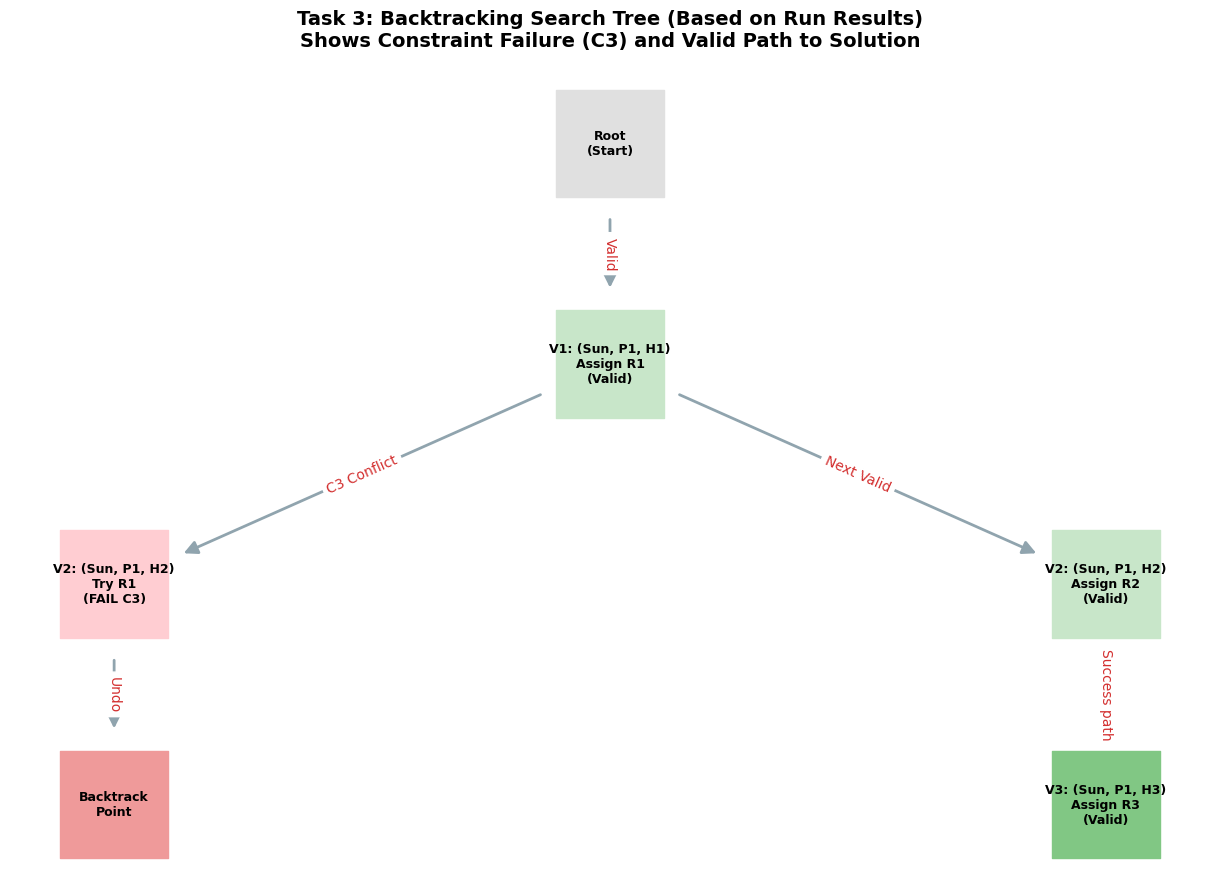

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_backtracking_results_tree():
    G = nx.DiGraph()
    
    # 1. Define Nodes based on your actual output
    # (Variable, Value/Outcome)
    nodes = {
        "Root": "Root\n(Start)",
        "V1_R1": "V1: (Sun, P1, H1)\nAssign R1\n(Valid)",
        "V2_Try_R1": "V2: (Sun, P1, H2)\nTry R1\n(FAIL C3)",
        "V2_R2": "V2: (Sun, P1, H2)\nAssign R2\n(Valid)",
        "V3_R3": "V3: (Sun, P1, H3)\nAssign R3\n(Valid)",
        "BT": "Backtrack\nPoint",
    }
    
    # Add nodes
    for node, label in nodes.items():
        G.add_node(node, label=label)
        
    # 2. Define Edges to show the search path
    edges = [
        ("Root", "V1_R1", "Valid"),
        ("V1_R1", "V2_Try_R1", "C3 Conflict"),
        ("V2_Try_R1", "BT", "Undo"),
        ("V1_R1", "V2_R2", "Next Valid"),
        ("V2_R2", "V3_R3", "Success path")
    ]
    
    for u, v, rel in edges:
        G.add_edge(u, v, label=rel)

    # 3. Professional Positioning (Hierarchical)
    pos = {
        "Root": (0, 10),
        "V1_R1": (0, 8),
        "V2_Try_R1": (-2, 6),
        "BT": (-2, 4),
        "V2_R2": (2, 6),
        "V3_R3": (2, 4)
    }

    plt.figure(figsize=(12, 8), facecolor='#f8f9fa')
    
    # 4. Color Coding: Green for the solution path, Red for conflicts
    node_colors = {
        "Root": "#e0e0e0",      # Grey
        "V1_R1": "#c8e6c9",     # Light Green
        "V2_Try_R1": "#ffcdd2", # Light Red
        "BT": "#ef9a9a",        # Red
        "V2_R2": "#c8e6c9",     # Light Green
        "V3_R3": "#81c784"      # Darker Green
    }
    
    colors = [node_colors[node] for node in G.nodes()]
    
    # Draw the tree
    nx.draw(G, pos, 
            with_labels=True, 
            labels=nodes, 
            node_shape="s", 
            node_color=colors, 
            node_size=6000, 
            font_size=9, 
            font_weight="bold", 
            edge_color='#90a4ae',
            width=2,
            arrowsize=20)
    
    # Add labels to explain the transitions (Constraints)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='#d32f2f', font_size=10)

    plt.title("Task 3: Backtracking Search Tree (Based on Run Results)\nShows Constraint Failure (C3) and Valid Path to Solution", 
              fontsize=14, fontweight='bold', pad=20)
    
    plt.axis('off')
    plt.show()

draw_backtracking_results_tree()

Question 4: MRV algorithm

In [134]:
import time

# --- 1. Problem Configuration ---
DAYS = ['Sun', 'Mon', 'Tue','Wed', 'Thu']
PERIODS = ['P1', 'P2', 'P3', 'P4']
HALLS = [f'H{i}' for i in range(1, 8)] 
PROCTORS = [f'R{i}' for i in range(1, 24)] 

variables = [(d, p, h) for d in DAYS for p in PERIODS for h in HALLS]

# Initialize domains with ALL proctors (don't use the rigid schedule)
domains = {var: PROCTORS[:] for var in variables}



# variables = [(d, p, h) for d in DAYS for p in PERIODS for h in HALLS ]
# proctor_schedules = {f'R{i}': [DAYS[i%5], DAYS[(i+1)%5], DAYS[(i+2)%5]] for i in range(1, 24)}

# # Initial Domains: Every variable starts with proctors scheduled for that day
# domains = {var: [p for p in PROCTORS if var[0] in proctor_schedules[p]] for var in variables}

# State Trackers
p_load = {(d, r): 0 for d in DAYS for r in PROCTORS}
p_busy = {(d, p, r): False for d in DAYS for p in PERIODS for r in PROCTORS}
p_hall = {(d, h, r): False for d in DAYS for h in HALLS for r in PROCTORS}

stats = {"backtrack_count": 0, "nodes": 0}

# Updated is_consistent to use your successful dynamic "days worked" logic
def is_consistent(var, proctor):
    day, period, hall = var
    
    # Dynamic Day Check
    days_worked = [d for d in DAYS if p_load[(d, proctor)] > 0]
    if day not in days_worked and len(days_worked) >= 3:
        return False
        
    if p_load[(day, proctor)] >= 3: return False
    if p_busy[(day, period, proctor)]: return False
    if p_hall[(day, hall, proctor)]: return False
    return True

# def is_consistent(var, proctor):
#     day, period, hall = var
#     if p_load[(day, proctor)] >= 3: return False
#     if p_busy[(day, period, proctor)]: return False
#     if p_hall[(day, hall, proctor)]: return False
#     return True

def get_mrv_variable(assignment):
    """Matches the 'mrv' logic in sudoku_enhanced.py"""
    unassigned = [v for v in variables if v not in assignment]
    if not unassigned: return None
    
    # Select variable with the smallest number of consistent remaining values
    return min(unassigned, key=lambda var: sum(1 for p in domains[var] if is_consistent(var, p)))

def backtrack(assignment):
    """The recursive structure from sudoku_enhanced.py"""
    stats["nodes"] += 1
    
    # 1. Select Variable using MRV
    var = get_mrv_variable(assignment)
    
    # Base Case: All assigned
    if var is None:
        return assignment

    # 2. Try values in the domain
    # In enhanced version, we iterate through the pre-filtered domain
    for proctor in domains[var]:
        if is_consistent(var, proctor):
            # Place
            assignment[var] = proctor
            d, p, h = var
            p_load[(d, proctor)] += 1
            p_busy[(d, p, proctor)] = True
            p_hall[(d, h, proctor)] = True

            # Recurse
            result = backtrack(assignment)
            if result:
                return result

            # Undo (Backtrack)
            p_load[(d, proctor)] -= 1
            p_busy[(d, p, proctor)] = False
            p_hall[(d, h, proctor)] = False
            del assignment[var]
            
    stats["backtrack_count"] += 1
    return None

# --- 4. Execution ---
print("=" * 40)
print("Exam Scheduling MRV Enhanced Backtracking Search")
print("=" * 40)

start_time = time.time()
solution = backtrack({})
end_time = time.time()

if solution:
    print(f"SUCCESS: Found in {end_time - start_time:.2f} seconds.")
    print(f"Nodes Explored: {stats['nodes']}")
    print(f"Backtrack Count: {stats['backtrack_count']}")
    
    print("\nSample Solution (First 20):")
    for var in variables[:20]:
        print(f"  Slot {var} -> Assigned: {solution[var]}")
else:
    print("FAILURE: No solution exists.")


Exam Scheduling MRV Enhanced Backtracking Search
SUCCESS: Found in 3.21 seconds.
Nodes Explored: 2830
Backtrack Count: 2689

Sample Solution (First 20):
  Slot ('Sun', 'P1', 'H1') -> Assigned: R1
  Slot ('Sun', 'P1', 'H2') -> Assigned: R2
  Slot ('Sun', 'P1', 'H3') -> Assigned: R3
  Slot ('Sun', 'P1', 'H4') -> Assigned: R4
  Slot ('Sun', 'P1', 'H5') -> Assigned: R5
  Slot ('Sun', 'P1', 'H6') -> Assigned: R6
  Slot ('Sun', 'P1', 'H7') -> Assigned: R7
  Slot ('Sun', 'P2', 'H1') -> Assigned: R2
  Slot ('Sun', 'P2', 'H2') -> Assigned: R7
  Slot ('Sun', 'P2', 'H3') -> Assigned: R1
  Slot ('Sun', 'P2', 'H4') -> Assigned: R3
  Slot ('Sun', 'P2', 'H5') -> Assigned: R4
  Slot ('Sun', 'P2', 'H6') -> Assigned: R5
  Slot ('Sun', 'P2', 'H7') -> Assigned: R6
  Slot ('Sun', 'P3', 'H1') -> Assigned: R3
  Slot ('Sun', 'P3', 'H2') -> Assigned: R1
  Slot ('Sun', 'P3', 'H3') -> Assigned: R8
  Slot ('Sun', 'P3', 'H4') -> Assigned: R9
  Slot ('Sun', 'P3', 'H5') -> Assigned: R2
  Slot ('Sun', 'P3', 'H6') -> 

Question 5: MRV+LCV

In [138]:
import time

# --- 1. Problem Configuration ---
DAYS = ['Sun', 'Mon', 'Tue','Wed', 'Thu']
PERIODS = ['P1', 'P2', 'P3', 'P4']
HALLS = [f'H{i}' for i in range(1, 8)] 
PROCTORS = [f'R{i}' for i in range(1, 24)] 

variables = [(d, p, h) for d in DAYS for p in PERIODS for h in HALLS]
proctor_schedules = {f'R{i}': [DAYS[i%5], DAYS[(i+1)%5], DAYS[(i+2)%5]] for i in range(1, 24)}

# --- 2. State Trackers & Stats ---
p_load = {(d, r): 0 for d in DAYS for r in PROCTORS}
p_busy = {(d, p, r): False for d in DAYS for p in PERIODS for r in PROCTORS}
p_hall = {(d, h, r): False for d in DAYS for h in HALLS for r in PROCTORS}

stats = {
    "nodes": 0,
    "backtrack_count": 0
}

def is_consistent(var, proctor):
    day, period, hall = var
    
    if day not in proctor_schedules[proctor]: return False
    
    # # Dynamic Day Check
    # days_worked = [d for d in DAYS if p_load[(d, proctor)] > 0]
    # if day not in days_worked and len(days_worked) >= 2:
    #     return False
        
    if p_load[(day, proctor)] >= 3: return False
    if p_busy[(day, period, proctor)]: return False
    if p_hall[(day, hall, proctor)]: return False
    return True

# --- MRV (Minimum Remaining Values) ---
def select_unassigned_variable(assignment):
    """Matches select_unassigned_variable in sudoku_enhanced.py"""
    unassigned = [v for v in variables if v not in assignment]
    if not unassigned:
        return None
    
    # Returns the variable with the minimum number of valid proctors remaining
    return min(unassigned, key=lambda var: sum(1 for p in PROCTORS if is_consistent(var, p)))

# --- LCV (Least Constraining Value) ---
def order_values_lcv(var):
    """Matches order_values_lcv logic in sudoku_enhanced.py"""
    legal_proctors = [p for p in PROCTORS if is_consistent(var, p)]
    
    def count_future_constraints(proctor):
        # In this context, a proctor's total workload acts as the constraint count.
        # Higher workload = more constraints on future slots.
        return sum(p_load[(d, proctor)] for d in DAYS)

    return sorted(legal_proctors, key=count_future_constraints)

# --- Backtracking Solver ---
def backtrack(assignment):
    """Recursive structure matching sudoku_enhanced.py"""
    stats["nodes"] += 1
    
    # 1. MRV Variable Selection
    var = select_unassigned_variable(assignment)
    if var is None:
        return assignment # All variables assigned

    # 2. LCV Value Ordering
    for proctor in order_values_lcv(var):
        # Place
        assignment[var] = proctor
        d, p, h = var
        p_load[(d, proctor)] += 1
        p_busy[(d, p, proctor)] = True
        p_hall[(d, h, proctor)] = True
        
        # 3. Recurse
        result = backtrack(assignment)
        if result:
            return result
        
        # 4. Backtrack
        p_load[(d, proctor)] -= 1
        p_busy[(d, p, proctor)] = False
        p_hall[(d, h, proctor)] = False
        del assignment[var]

    stats["backtrack_count"] += 1
    return None

# --- 4. Execution ---
print("=" * 40)
print("Exam Scheduling MRV Enhanced Backtracking Search")
print("=" * 40)

start_time = time.time()
solution = backtrack({})
end_time = time.time()

if solution:
    print(f"SUCCESS: Found in {end_time - start_time:.2f} seconds.")
    print(f"Nodes Explored: {stats['nodes']}")
    print(f"Backtrack Count: {stats['backtrack_count']}")
    
    print("\nSample Solution (First 20):")
    for var in variables[:20]:
        print(f"  Slot {var} -> Assigned: {solution[var]}")
else:
    print("FAILURE: No solution exists.")


Exam Scheduling MRV Enhanced Backtracking Search
SUCCESS: Found in 0.12 seconds.
Nodes Explored: 141
Backtrack Count: 0

Sample Solution (First 20):
  Slot ('Sun', 'P1', 'H1') -> Assigned: R3
  Slot ('Sun', 'P1', 'H2') -> Assigned: R4
  Slot ('Sun', 'P1', 'H3') -> Assigned: R5
  Slot ('Sun', 'P1', 'H4') -> Assigned: R8
  Slot ('Sun', 'P1', 'H5') -> Assigned: R9
  Slot ('Sun', 'P1', 'H6') -> Assigned: R10
  Slot ('Sun', 'P1', 'H7') -> Assigned: R13
  Slot ('Sun', 'P2', 'H1') -> Assigned: R14
  Slot ('Sun', 'P2', 'H2') -> Assigned: R15
  Slot ('Sun', 'P2', 'H3') -> Assigned: R18
  Slot ('Sun', 'P2', 'H4') -> Assigned: R19
  Slot ('Sun', 'P2', 'H5') -> Assigned: R20
  Slot ('Sun', 'P2', 'H6') -> Assigned: R23
  Slot ('Sun', 'P2', 'H7') -> Assigned: R3
  Slot ('Sun', 'P3', 'H1') -> Assigned: R4
  Slot ('Sun', 'P3', 'H2') -> Assigned: R13
  Slot ('Sun', 'P3', 'H3') -> Assigned: R8
  Slot ('Sun', 'P3', 'H4') -> Assigned: R14
  Slot ('Sun', 'P3', 'H5') -> Assigned: R5
  Slot ('Sun', 'P3', 'H6

Question 6: AC-3


In [139]:
import time
from collections import deque
import copy

# --- 1. Problem Configuration ---
DAYS = ['Sun', 'Mon', 'Tue','Wed', 'Thu']
PERIODS = ['P1', 'P2', 'P3', 'P4']
HALLS = [f'H{i}' for i in range(1, 8)] 
PROCTORS = [f'R{i}' for i in range(1, 24)] 

variables = [(d, p, h)  for d in DAYS for p in PERIODS for h in HALLS]
proctor_schedules = {f'R{i}': [DAYS[i%5], DAYS[(i+1)%5], DAYS[(i+2)%5]] for i in range(1, 24)}

# Initial Domains based on proctor schedules
initial_domains = {var: {p for p in PROCTORS if var[0] in proctor_schedules[p]} for var in variables}

stats = {
    "backtrack_count": 0,
    "domain_reductions": 0,
    "nodes": 0
}

# --- 2. Neighbors & Consistency Logic ---
def get_neighbors():
    neighbors = {var: set() for var in variables}
    for v1 in variables:
        d1, p1, h1 = v1
        for v2 in variables:
            if v1 == v2: continue
            d2, p2, h2 = v2
            if (d1 == d2 and p1 == p2) or (d1 == d2 and h1 != h2):
                neighbors[v1].add(v2)
    return neighbors

def is_consistent(v1, val1, v2, val2):
    d1, p1, h1 = v1
    d2, p2, h2 = v2
    if val1 == val2:
        if d1 == d2 and p1 == p2: return False 
        if d1 == d2 and h1 != h2: return False 
    return True

# --- 3. AC-3 Functions (Matched to sudoku_enhanced.py) ---
def ac3(domains, neighbors, stats):
    queue = deque([(xi, xj) for xi in variables for xj in neighbors[xi]])
    while queue:
        xi, xj = queue.popleft()
        if revise(domains, xi, xj, stats):
            if not domains[xi]: return False
            for xk in neighbors[xi]:
                if xk != xj: queue.append((xk, xi))
    return True

def revise(domains, xi, xj, stats):
    revised = False
    to_remove = set()
    for x in domains[xi]:
        if not any(is_consistent(xi, x, xj, y) for y in domains[xj]):
            to_remove.add(x)
    if to_remove:
        if stats["domain_reductions"] < 5: 
            print(f"[AC-3 Reduction] Removed {list(to_remove)[:2]} from Slot {xi}")
        stats["domain_reductions"] += len(to_remove)
        domains[xi] -= to_remove
        revised = True
    return revised

# --- 4. Basic Backtracking with AC-3 Enhancement ---

def select_next_variable(assignment):
    """BASIC: Just picks the next unassigned variable in the list."""
    for var in variables:
        if var not in assignment:
            return var
    return None

def backtrack(domains, neighbors, assignment):
    """Enhanced Backtracking using only AC-3 (MAC)."""
    stats["nodes"] += 1
    
    # Selection: BASIC (No MRV)
    var = select_next_variable(assignment)
    if var is None: return assignment 

    # Value Ordering: BASIC (No LCV - just use original proctor list)
    # We sort the set to ensure deterministic behavior, but no heuristic is applied.
    values_to_try = sorted(list(domains[var]))

    for value in values_to_try:
        # Create a deep copy for this branch
        new_domains = copy.deepcopy(domains)
        new_domains[var] = {value}
        
        # MAC: Maintaining Arc Consistency via AC-3
        if ac3(new_domains, neighbors, stats):
            new_assignment = assignment.copy()
            new_assignment[var] = value
            
            result = backtrack(new_domains, neighbors, new_assignment)
            if result: return result
            
    stats["backtrack_count"] += 1
    return None

# --- 5. Execution ---
print("=" * 40)
print("Basic Backtracking + AC-3 Enhancement")
print("=" * 40)

neighbors = get_neighbors()
start_time = time.time()

# Initial AC-3 Pruning
ac3(initial_domains, neighbors, stats)
final_solution = backtrack(initial_domains, neighbors, {})

end_time = time.time()

if final_solution:
    print(f"SUCCESS in {end_time - start_time:.4f}s")
    print(f"Nodes: {stats['nodes']} | Backtracks: {stats['backtrack_count']}")
    print(f"Total Domain Reductions: {stats['domain_reductions']}")
else:
    print("No solution found.")

Basic Backtracking + AC-3 Enhancement
[AC-3 Reduction] Removed ['R10'] from Slot ('Sun', 'P1', 'H2')
[AC-3 Reduction] Removed ['R10'] from Slot ('Sun', 'P1', 'H3')
[AC-3 Reduction] Removed ['R10'] from Slot ('Sun', 'P1', 'H4')
[AC-3 Reduction] Removed ['R10'] from Slot ('Sun', 'P1', 'H5')
[AC-3 Reduction] Removed ['R10'] from Slot ('Sun', 'P1', 'H6')
SUCCESS in 2.7144s
Nodes: 141 | Backtracks: 0
Total Domain Reductions: 735
